In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import numpy as np

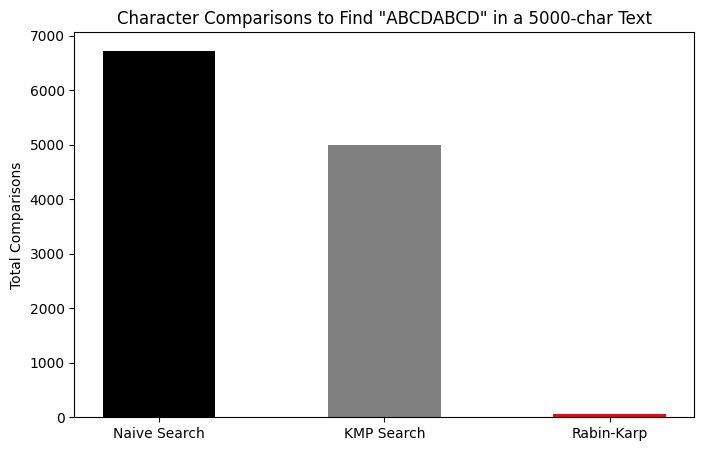

In [6]:
import random
import matplotlib.pyplot as plt

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0
    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]: break
            j += 1
    return comparisons

def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length, i = 0, 1
    while i < m:
        if pattern[i] == pattern[length]:
            length += 1; lps[i] = length; i += 1
        elif length != 0: length = lps[length - 1]
        else: lps[i] = 0; i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comparisons, i, j = 0, 0, 0
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]: i += 1; j += 1
        if j == m: j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0: j = lps[j - 1]
            else: i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comparisons, i, j = 0, 0, 0
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]: i += 1; j += 1
        if j == m: j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0: j = lps[j - 1]
            else: i += 1
    return comparisons

def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d = 256
    h = pow(d, m - 1, q)
    p_hash = t_hash = 0
    comparisons = 0
    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q
    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comparisons += 1
                if text[s + k] != pattern[k]: break
        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q
            if t_hash < 0: t_hash += q
    return comparisons

text = ''.join(random.choices('ABCD', k=5000))
pattern = 'ABCDABCD'

naive_comps = naive_search(text, pattern)
kmp_comps = kmp_search(text, pattern)
rk_comps = rabin_karp(text, pattern)


algorithms = ['Naive Search', 'KMP Search', 'Rabin-Karp']
comparison_values = [naive_comps, kmp_comps, rk_comps]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, comparison_values, color=['black', 'grey', 'red'], width=0.5)
plt.title('Character Comparisons to Find "ABCDABCD" in a 5000-char Text')
plt.ylabel('Total Comparisons')
plt.show()